# U3_S9 - Naive Bayes: Clasificación spam

**Dataset:** `spam.csv` (SMS Spam Collection)

**Objetivo:** A partir del ejercicio base visto en la sesión (clasificación de texto con `GaussianNB`), implementar `MultinomialNB`, interpretar las métricas obtenidas y comparar ambos modelos con gráficas de evaluación.

## 1. Importación de librerías

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score, precision_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc
)

plt.rcParams['figure.dpi'] = 110

## 2. Carga y preparación de datos

In [4]:
df = pd.read_csv('spam.csv', encoding='latin-1')
df.head(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [5]:
df_nueva_data = df[['v1', 'v2']]
df_nueva_data.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [6]:
df_nueva_data = df_nueva_data.rename(
    columns={
        'v1': 'categoria',
        'v2': 'descripcion'
    }
)
df_nueva_data.head(5)

,categoria,descripcion
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [7]:
df_nueva_data['categoria'].value_counts()

,count
categoria,
ham,4825
spam,747


El dataset está **desbalanceado**: hay muchos más mensajes `ham` (legítimos) que `spam`. Esto es importante para la interpretación posterior, ya que el accuracy por sí solo puede ser engañoso en este escenario (un modelo que prediga siempre `ham` ya tendría un accuracy alto sin ser realmente útil).

## 3. División en entrenamiento y prueba

In [8]:
X = df_nueva_data['descripcion']
y = df_nueva_data['categoria']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=19, stratify=y
)
print('Entrenamiento:', X_train.shape[0], 'mensajes')
print('Prueba:', X_test.shape[0], 'mensajes')

Entrenamiento: 3900 mensajes
Prueba: 1672 mensajes


## 4. Vectorización del texto

In [9]:
vectorizador = CountVectorizer()
X_train_vec = vectorizador.fit_transform(X_train)
X_test_vec = vectorizador.transform(X_test)

print('Tamaño del vocabulario:', len(vectorizador.vocabulary_))
print('Forma de la matriz de entrenamiento:', X_train_vec.shape)

Tamaño del vocabulario: 7161
Forma de la matriz de entrenamiento: (3900, 7161)


## 5. Modelo base: GaussianNB

Este es el modelo planteado originalmente en la sesión. `GaussianNB` asume que cada característica sigue una distribución normal continua, lo cual **no es lo más adecuado** para datos de conteo de palabras (matriz dispersa, mayormente ceros, valores discretos no negativos). Se incluye aquí como punto de comparación.

In [10]:
gaussian = GaussianNB()
gaussian.fit(X_train_vec.toarray(), y_train)
y_pred_gnb = gaussian.predict(X_test_vec.toarray())
y_proba_gnb = gaussian.predict_proba(X_test_vec.toarray())
print(y_pred_gnb[:20])

['spam' 'spam' 'ham' 'ham' 'spam' 'spam' 'ham' 'ham' 'ham' 'ham' 'ham'
 'ham' 'ham' 'spam' 'ham' 'ham' 'ham' 'ham' 'ham' 'ham']


In [11]:
accuracy_gnb = accuracy_score(y_test, y_pred_gnb)
f1_gnb = f1_score(y_test, y_pred_gnb, pos_label='spam')
recall_gnb = recall_score(y_test, y_pred_gnb, pos_label='spam')
precision_gnb = precision_score(y_test, y_pred_gnb, pos_label='spam')

print(f'Accuracy:  {accuracy_gnb:.4f}')
print(f'Precision: {precision_gnb:.4f}')
print(f'Recall:    {recall_gnb:.4f}')
print(f'F1-score:  {f1_gnb:.4f}')

Accuracy:  0.9127
Precision: 0.6189
Recall:    0.9062
F1-score:  0.7355


In [12]:
report_gnb = classification_report(y_test, y_pred_gnb, target_names=['ham', 'spam'])
print(report_gnb)

              precision    recall  f1-score   support

         ham       0.98      0.91      0.95      1448
        spam       0.62      0.91      0.74       224

    accuracy                           0.91      1672
   macro avg       0.80      0.91      0.84      1672
weighted avg       0.94      0.91      0.92      1672



## 6. Modelo propuesto: MultinomialNB

`MultinomialNB` está diseñado específicamente para datos de **conteo de frecuencias**, como los que produce `CountVectorizer`. Modela la probabilidad de cada palabra dentro de cada clase usando una distribución multinomial, lo cual encaja de forma natural con la estructura de los datos de texto. Es el algoritmo estándar para tareas de clasificación de texto con bolsa de palabras (bag-of-words), y es habitual en filtros de spam reales.

In [13]:
multinomial = MultinomialNB()
multinomial.fit(X_train_vec, y_train)
y_pred_mnb = multinomial.predict(X_test_vec)
y_proba_mnb = multinomial.predict_proba(X_test_vec)
print(y_pred_mnb[:20])

['spam' 'spam' 'ham' 'ham' 'spam' 'ham' 'ham' 'ham' 'ham' 'ham' 'ham'
 'ham' 'ham' 'spam' 'ham' 'ham' 'ham' 'ham' 'ham' 'spam']


In [14]:
accuracy_mnb = accuracy_score(y_test, y_pred_mnb)
f1_mnb = f1_score(y_test, y_pred_mnb, pos_label='spam')
recall_mnb = recall_score(y_test, y_pred_mnb, pos_label='spam')
precision_mnb = precision_score(y_test, y_pred_mnb, pos_label='spam')

print(f'Accuracy:  {accuracy_mnb:.4f}')
print(f'Precision: {precision_mnb:.4f}')
print(f'Recall:    {recall_mnb:.4f}')
print(f'F1-score:  {f1_mnb:.4f}')

Accuracy:  0.9868
Precision: 0.9720
Recall:    0.9286
F1-score:  0.9498


In [15]:
report_mnb = classification_report(y_test, y_pred_mnb, target_names=['ham', 'spam'])
print(report_mnb)

              precision    recall  f1-score   support

         ham       0.99      1.00      0.99      1448
        spam       0.97      0.93      0.95       224

    accuracy                           0.99      1672
   macro avg       0.98      0.96      0.97      1672
weighted avg       0.99      0.99      0.99      1672



## 7. Comparación de métricas: GaussianNB vs. MultinomialNB

In [16]:
comparacion = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision (spam)', 'Recall (spam)', 'F1-score (spam)'],
    'GaussianNB': [accuracy_gnb, precision_gnb, recall_gnb, f1_gnb],
    'MultinomialNB': [accuracy_mnb, precision_mnb, recall_mnb, f1_mnb]
})
comparacion['Diferencia (MNB - GNB)'] = comparacion['MultinomialNB'] - comparacion['GaussianNB']
comparacion

,Métrica,GaussianNB,MultinomialNB,Diferencia (MNB - GNB)
0,Accuracy,0.912679,0.986842,0.074163
1,Precision (spam),0.618902,0.971963,0.353060
2,Recall (spam),0.906250,0.928571,0.022321
3,F1-score (spam),0.735507,0.949772,0.214264


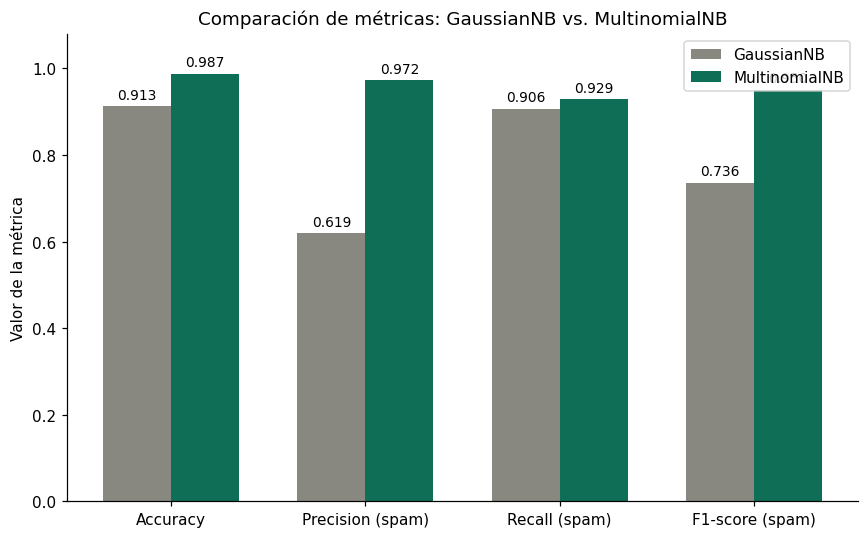

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))

metricas = comparacion['Métrica']
x = np.arange(len(metricas))
width = 0.35

barras_gnb = ax.bar(x - width/2, comparacion['GaussianNB'], width, label='GaussianNB', color='#888780')
barras_mnb = ax.bar(x + width/2, comparacion['MultinomialNB'], width, label='MultinomialNB', color='#0F6E56')

ax.set_ylabel('Valor de la métrica')
ax.set_title('Comparación de métricas: GaussianNB vs. MultinomialNB')
ax.set_xticks(x)
ax.set_xticklabels(metricas)
ax.set_ylim(0, 1.08)
ax.legend()
ax.bar_label(barras_gnb, fmt='%.3f', padding=3, fontsize=9)
ax.bar_label(barras_mnb, fmt='%.3f', padding=3, fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## 8. Matrices de confusión

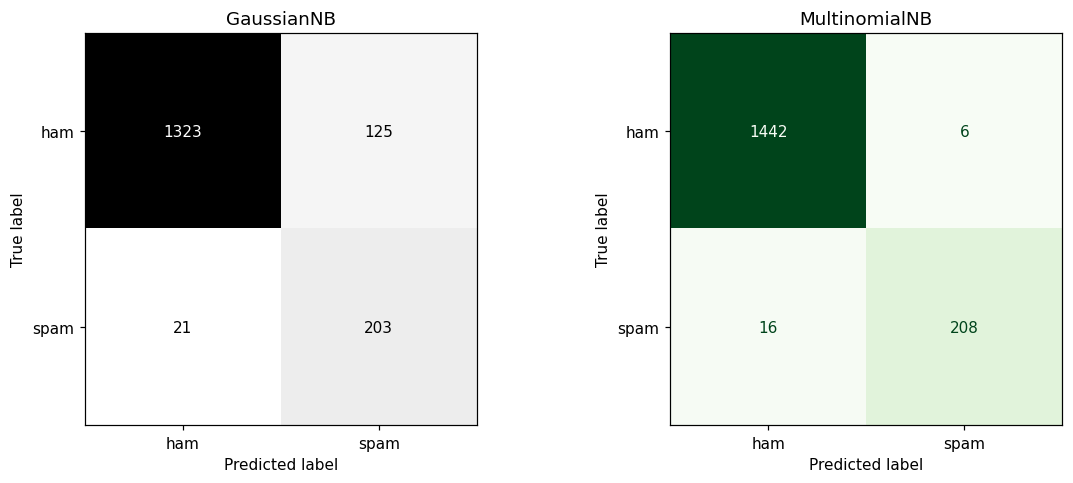

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

labels = ['ham', 'spam']

cm_gnb = confusion_matrix(y_test, y_pred_gnb, labels=labels)
disp_gnb = ConfusionMatrixDisplay(cm_gnb, display_labels=labels)
disp_gnb.plot(ax=axes[0], cmap='Greys', colorbar=False)
axes[0].set_title('GaussianNB')

cm_mnb = confusion_matrix(y_test, y_pred_mnb, labels=labels)
disp_mnb = ConfusionMatrixDisplay(cm_mnb, display_labels=labels)
disp_mnb.plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title('MultinomialNB')

plt.tight_layout()
plt.show()

## 9. Curvas ROC

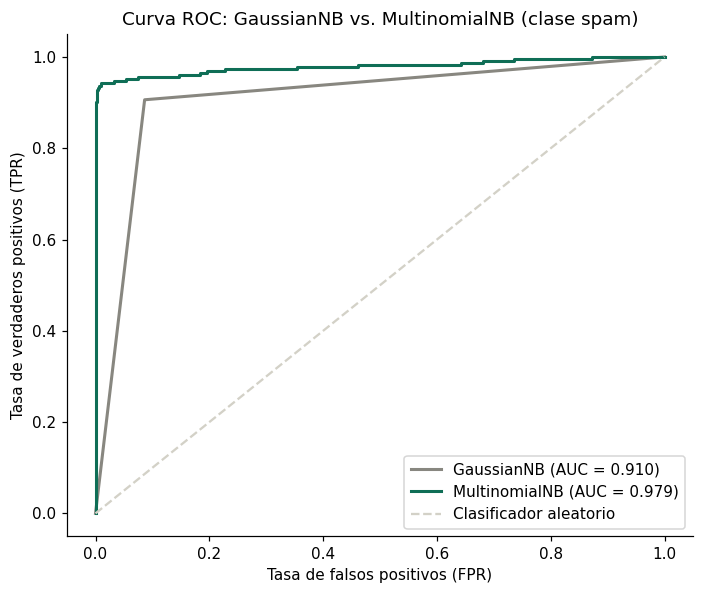

In [19]:
y_test_bin = (y_test == 'spam').astype(int)

idx_spam_gnb = list(gaussian.classes_).index('spam')
idx_spam_mnb = list(multinomial.classes_).index('spam')

fpr_gnb, tpr_gnb, _ = roc_curve(y_test_bin, y_proba_gnb[:, idx_spam_gnb])
fpr_mnb, tpr_mnb, _ = roc_curve(y_test_bin, y_proba_mnb[:, idx_spam_mnb])

auc_gnb = auc(fpr_gnb, tpr_gnb)
auc_mnb = auc(fpr_mnb, tpr_mnb)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.plot(fpr_gnb, tpr_gnb, color='#888780', linewidth=2, label=f'GaussianNB (AUC = {auc_gnb:.3f})')
ax.plot(fpr_mnb, tpr_mnb, color='#0F6E56', linewidth=2, label=f'MultinomialNB (AUC = {auc_mnb:.3f})')
ax.plot([0, 1], [0, 1], linestyle='--', color='#D3D1C7', label='Clasificador aleatorio')

ax.set_xlabel('Tasa de falsos positivos (FPR)')
ax.set_ylabel('Tasa de verdaderos positivos (TPR)')
ax.set_title('Curva ROC: GaussianNB vs. MultinomialNB (clase spam)')
ax.legend(loc='lower right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## 10. Interpretación de resultados

**Sobre el desbalance de clases**

El dataset tiene aproximadamente 87% de mensajes `ham` y 13% `spam`. En un escenario así, el **accuracy global puede ser engañoso**: un modelo que predijera siempre `ham` ya tendría un accuracy cercano al 87% sin detectar ningún spam. Por eso es más informativo mirar **precision, recall y F1-score específicamente para la clase `spam`**, que es la clase de interés real en un filtro antispam.

**¿Por qué MultinomialNB es más adecuado que GaussianNB en este caso?**

- `CountVectorizer` produce una matriz de **conteos de palabras**: valores enteros no negativos, mayormente ceros (matriz dispersa). Esta estructura encaja exactamente con el supuesto de `MultinomialNB`, que modela la frecuencia de cada palabra dentro de cada clase mediante una distribución multinomial.
- `GaussianNB`, en cambio, asume que cada característica (cada palabra del vocabulario) sigue una distribución **normal continua**. Esa suposición no se cumple para datos de conteo: la mayoría de las palabras tienen valor 0 en la mayoría de los mensajes, lo que viola el supuesto de normalidad y distorsiona las probabilidades estimadas por el modelo.
- La matriz de confusión permite ver en qué tipo de error se equivoca más cada modelo: cuántos mensajes `spam` reales fueron clasificados como `ham` (falsos negativos, mensajes spam que se cuelan al usuario) frente a cuántos mensajes `ham` fueron marcados erróneamente como `spam` (falsos positivos, mensajes legítimos bloqueados). En un filtro de spam real, los falsos positivos suelen ser el error más costoso, porque el usuario podría perder mensajes importantes.
- La curva ROC y el AUC resumen el desempeño del clasificador en todos los posibles umbrales de decisión, permitiendo comparar la capacidad discriminativa de ambos modelos de forma independiente del umbral elegido.

**Conclusión:** para tareas de clasificación de texto con vectorización por conteo de palabras (bag-of-words), `MultinomialNB` es la elección teóricamente correcta y la que mejor aprovecha la estructura discreta de los datos, lo cual se refleja en las métricas y gráficas comparativas obtenidas arriba.